<a href="https://colab.research.google.com/github/svevo6/Projet-IA/blob/main/Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samxsam/human-cognitive-performance-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-cognitive-performance-analysis' dataset.
Path to dataset files: /kaggle/input/human-cognitive-performance-analysis


In [8]:
df = pd.read_csv('/kaggle/input/human-cognitive-performance-analysis/human_cognitive_performance.csv')

print(" Dimenions du dataset:")
print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

print("\n Infos du dataset:")
print(df.info())

 Dimenions du dataset:
Shape: (80000, 13) (Rows: 80000, Columns: 13)

 Infos du dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB
None


In [9]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


En examinant le df.head() on comprend que la variable AI_predicted_Score avait pour but de prédire Cognitive_Score. En effet les valeurs numériques des deux variables sont très proches à chaque ligne.

Partie 1 : Preprocessing

In [10]:
print('Data types:')
print(df.dtypes)

missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("\n Il n'y a pas de valeurs manquantes")

if (df.isna().values.any()==0) :
  print("\n Il n'y a pas non plus de Nan")

Data types:
User_ID                object
Age                     int64
Gender                 object
Sleep_Duration        float64
Stress_Level            int64
Diet_Type              object
Daily_Screen_Time     float64
Exercise_Frequency     object
Caffeine_Intake         int64
Reaction_Time         float64
Memory_Test_Score       int64
Cognitive_Score       float64
AI_Predicted_Score    float64
dtype: object
Series([], dtype: int64)

 Il n'y a pas de valeurs manquantes

 Il n'y a pas non plus de Nan


On choisit Cognitive_Score comme target d'après la remarque qu'on a fait précédemment.

Pour nos features, on choisit :  

1.  Age
2.    Gender
3. Sleep_Duration
4. Stress_Level
5. Diet_Type
6. Daily_Screen_Time
7. Exercise_Frequency
8. Caffeine_Intake.
9. Reaction_Time
10. Memory_Test_Score

  Ce sont des variables explicatives représentant la physiologie, l'hygiène de vie et la charge mentale des sujets.

  User_ID est un indentifiant, donc ne répresente aucune info prédictive, donc elle est à exclure.
  D'autre part, AI_Predicted_Score est déjà un output d'un modèle IA donc on l'exclut pour éviter les dataleakage.
  
  


In [11]:
y = df["Cognitive_Score"]
X = df.drop(columns=[
    "Cognitive_Score",
    "User_ID",
    "AI_Predicted_Score"
])


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

On doit à présent séparer les features numériques des features catégorielles.

In [13]:
num_features = [
    "Age",
    "Sleep_Duration",
    "Stress_Level",
    "Daily_Screen_Time",
    "Caffeine_Intake",
    "Reaction_Time",
    "Memory_Test_Score"
]

cat_features = [
    "Gender",
    "Diet_Type",
    "Exercise_Frequency"
]

On construit donc le prépropcesseur.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

Partie 2 : Modélisation

Modèle A : Régression linéaire

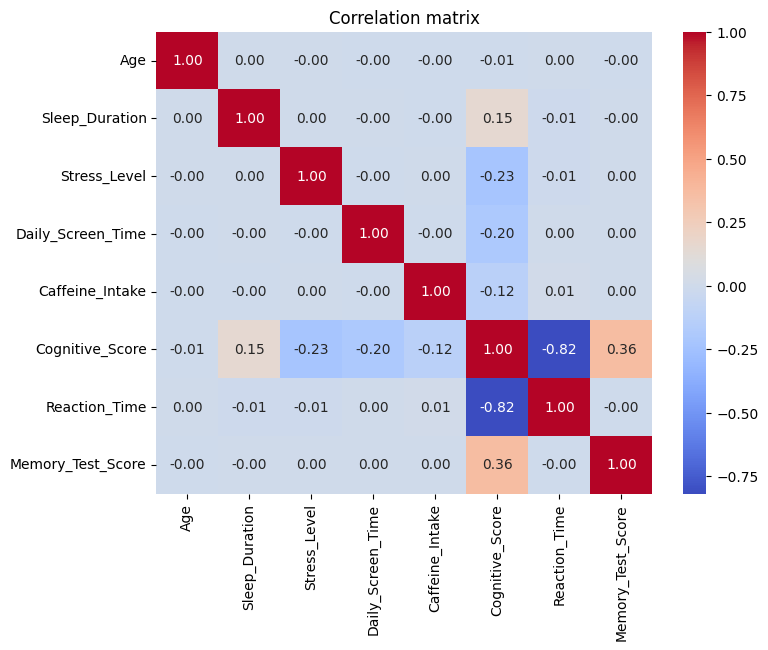

In [15]:
num_cols = [
    "Age",
    "Sleep_Duration",
    "Stress_Level",
    "Daily_Screen_Time",
    "Caffeine_Intake",
    "Cognitive_Score",
    "Reaction_Time",
    "Memory_Test_Score"
]

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

Nous allons commencer par un modèle de regression linéaire puisque notre target est une variable continue, et que l'on note une très forte corrélation entre notre target et le temps de réaction. C'est un modèle simple qui nous servira de référence pour la suite.

In [16]:
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

lin_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Sleep_Duration',
                                                   'Stress_Level',
                                                   'Daily_Screen_Time',
                                                   'Caffeine_Intake',
                                                   'Reaction_Time',
                                                   'Memory_Test_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Diet_Type',
                                                   'Exercise_Frequency'])])),
                ('model', LinearRegression())])

On peut alors évaluer notre modèle.

In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

RMSE : 1.498
R²   : 0.996


In [18]:
y_train_pred = lin_reg.predict(X_train)

print("Train R²:", r2_score(y_train, y_train_pred))

Train R²: 0.995760971778571


Le modèle est donc ni underfitted, ni overfitted.

Comme attendu au vu de la matrice de corrélation, les performances du modèles sont très bonnes puisque le R^2 est quasiment égal à 1 et que la rmse est sensiblement proche de 0.

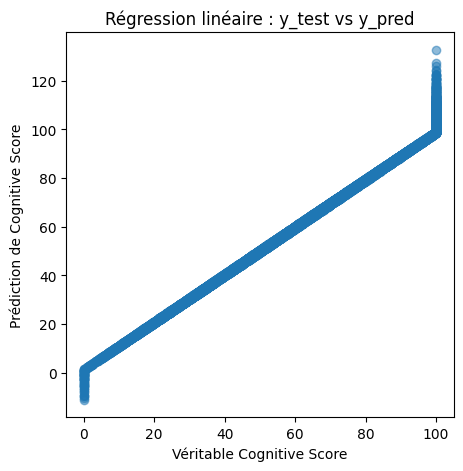

In [19]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Véritable Cognitive Score")
plt.ylabel("Prédiction de Cognitive Score")
plt.title("Régression linéaire : y_test vs y_pred")
plt.show()

Modèle B : Régression linéaire BIS

Dans le premier modèle, certaines features sont des variables cognitives. Dans un but d'analyse explicative (notamment à des fins médicales) il serait scientifiquemet plus intéressant de garder en features des variables phisiologiques et comportementaux. Donc enlever time_reaction et Memory_score des features.

In [20]:
num_features2 = [
    "Age",
    "Sleep_Duration",
    "Stress_Level",
    "Daily_Screen_Time",
    "Caffeine_Intake",
]

cat_features2 = [
    "Gender",
    "Diet_Type",
    "Exercise_Frequency",
]

X2 = df[num_features2 + cat_features2].copy()
y2 = df["Cognitive_Score"].copy()


X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features2),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None), cat_features2),
    ]
)

lin_reg2 = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("reg", LinearRegression()),
    ]
)

lin_reg2.fit(X_train2, y_train2)

y_pred2 = lin_reg2.predict(X_test2)
r2 = r2_score(y_test2, y_pred2)
mse = mean_squared_error(y_test2, y_pred2)

print(f"R² = {r2:.4f}")
print(f"MSE = {mse:.4f}")

R² = 0.1846
MSE = 430.6157


Les performances prédictives du modèles sont évidemment moins bonnes à présent puisque le modème repose uniquement sur les variables phisiologiques et comportementales, qui influent moins directement le score cognifif.
Dans un contexte d'analyse explicative, la performance prédictive n'est pas l'objectif principal.

On veut analyser les coefficients de la regression

In [21]:
pre = lin_reg2.named_steps["preprocess"]
reg = lin_reg2.named_steps["reg"]

feature_names = pre.get_feature_names_out()
coeffs = pd.Series(reg.coef_, index=feature_names)

coeffs_sorted = coeffs.sort_values(key=abs, ascending=False)
print(coeffs_sorted)

cat__Exercise_Frequency_Low      -8.173948
cat__Exercise_Frequency_High      6.478248
num__Stress_Level                -5.338113
num__Daily_Screen_Time           -4.592618
num__Sleep_Duration               3.454209
num__Caffeine_Intake             -2.863396
cat__Exercise_Frequency_Medium    1.695700
cat__Diet_Type_Non-Vegetarian     0.170568
cat__Gender_Other                -0.136155
num__Age                         -0.110527
cat__Diet_Type_Vegan             -0.092100
cat__Gender_Female                0.087150
cat__Diet_Type_Vegetarian        -0.078469
cat__Gender_Male                  0.049005
dtype: float64


On remarque un effet très marqué de Exercis_Frequency.
D'une part, une faible fréquence d'exercice est associée à une diminution très importante du score cognitif.
D'autre part, une fréquence élevée est associée à une diminution très importante du score cognitif.

Le stress et l'exposition aux écran ont également un impact sensible sur la baisse de la performance cognitive.

Alors que le sommeil a un effet positif (plus modéré que le stress ou l'exercice).

On remarque que les effets du régime alimentaire, le genre ou l'âge semblent négligeables.

Modèle C : Random Forest

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [24]:
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Sleep_Duration',
                                                   'Stress_Level',
                                                   'Daily_Screen_Time',
                                                   'Caffeine_Intake',
                                                   'Reaction_Time',
                                                   'Memory_Test_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Diet_Type',
                                                   'Exercise_Frequency'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [25]:
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE : {rmse_rf:.3f}")
print(f"Random Forest R²   : {r2_rf:.3f}")

Random Forest RMSE : 2.560
Random Forest R²   : 0.988


In [26]:
y_train_pred_rf = rf.predict(X_train)

print("Train R²:", r2_score(y_train, y_train_pred_rf))

Train R²: 0.9982422495846542


Ni overfitted, ni underfitted.

In [27]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse, rmse_rf],
    "R2": [r2, r2_rf]
})

results

,Model,RMSE,R2
0,Linear Regression,1.498014,0.184607
1,Random Forest,2.560360,0.987587


La random forest est moins performante que la regression linéaire du modèle A mais reste objectivement un bon modèle également. Cela veut dire que la quasi-linéairité entre la target et reaction time l'emporte sur les relation non-linéaires entre les variables de mode de vie et la target.

On garde donc la regression linéaire pour le réseau de neurones.

Partie 3 : Réseau de neurones

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [29]:
preprocessor_nn = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

In [30]:
X_train_nn = preprocessor_nn.fit_transform(X_train)
X_test_nn  = preprocessor_nn.transform(X_test)

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [32]:
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [227]:
model = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1)
])

Couche d'entrée : nombre de features

couche cachée 1 : 8 neurones, activation ReLU

couche cachée 2 : 4 neurones, activation ReLu

couche de sortie : 1 neurone (pas d'activation car regression)

Architecture décroissante. En testant, on observe que mettre plus de neurones n'augmente pas la précision.

In [228]:
# Compile your model.
model.compile(loss='mse', optimizer='adam',metrics=['mae'])

La loss utilisée est la MSE puisque le modèle est une régression.

In [35]:
def utils_nn_config(model):
    lst_layers = []
    if "Sequential" in str(model): #-> Sequential doesn't show the input layer
        layer = model.layers[0]
        lst_layers.append({"name":"input", "in":int(layer.input.shape[-1]), "neurons":0,
                           "out":int(layer.input.shape[-1]), "activation":None,
                           "params":0, "bias":0})
    for layer in model.layers:
        try:
            dic_layer = {"name":layer.name, "in":int(layer.input.shape[-1]), "neurons":layer.units,
                         "out":int(layer.output.shape[-1]), "activation":layer.get_config()["activation"],
                         "params":layer.get_weights()[0], "bias":layer.get_weights()[1]}
        except:
            dic_layer = {"name":layer.name, "in":int(layer.input.shape[-1]), "neurons":0,
                         "out":int(layer.output.shape[-1]), "activation":None,
                         "params":0, "bias":0}
        lst_layers.append(dic_layer)
    return lst_layers

def visualize_nn(model, description=False, figsize=(10,8)):
    ## get layers info
    lst_layers = utils_nn_config(model)
    layer_sizes = [layer["out"] for layer in lst_layers]

    ## fig setup
    fig = plt.figure(figsize=figsize)
    ax = fig.gca()
    ax.set(title=model.name)
    ax.axis('off')
    left, right, bottom, top = 0.1, 0.9, 0.1, 0.9
    x_space = (right-left) / float(len(layer_sizes)-1)
    y_space = (top-bottom) / float(max(layer_sizes))
    p = 0.025

    ## nodes
    for i,n in enumerate(layer_sizes):
        top_on_layer = y_space*(n-1)/2.0 + (top+bottom)/2.0
        layer = lst_layers[i]
        color = "green" if i in [0, len(layer_sizes)-1] else "blue"
        color = "red" if (layer['neurons'] == 0) and (i > 0) else color

        ### add description
        if (description is True):
            d = i if i == 0 else i-0.5
            if layer['activation'] is None:
                plt.text(x=left+d*x_space, y=top, fontsize=10, color=color, s=layer["name"].upper())
            else:
                plt.text(x=left+d*x_space, y=top, fontsize=10, color=color, s=layer["name"].upper())
                plt.text(x=left+d*x_space, y=top-p, fontsize=10, color=color, s=layer['activation']+" (")
                plt.text(x=left+d*x_space, y=top-2*p, fontsize=10, color=color, s="Σ"+str(layer['in'])+"[X*w]+b")
                out = " Y"  if i == len(layer_sizes)-1 else " out"
                plt.text(x=left+d*x_space, y=top-3*p, fontsize=10, color=color, s=") = "+str(layer['neurons'])+out)

        ### circles
        for m in range(n):
            color = "limegreen" if color == "green" else color
            circle = plt.Circle(xy=(left+i*x_space, top_on_layer-m*y_space-4*p), radius=y_space/4.0, color=color, ec='k', zorder=4)
            ax.add_artist(circle)

            ### add text
            if i == 0:
                plt.text(x=left-4*p, y=top_on_layer-m*y_space-4*p, fontsize=10, s=r'$X_{'+str(m+1)+'}$')
            elif i == len(layer_sizes)-1:
                plt.text(x=right+4*p, y=top_on_layer-m*y_space-4*p, fontsize=10, s=r'$y_{'+str(m+1)+'}$')
            else:
                plt.text(x=left+i*x_space+p, y=top_on_layer-m*y_space+(y_space/8.+0.01*y_space)-4*p, fontsize=10, s=r'$H_{'+str(m+1)+'}$')

    ## links
    for i, (n_a, n_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer = lst_layers[i+1]
        color = "green" if i == len(layer_sizes)-2 else "blue"
        color = "red" if layer['neurons'] == 0 else color
        layer_top_a = y_space*(n_a-1)/2. + (top+bottom)/2. -4*p
        layer_top_b = y_space*(n_b-1)/2. + (top+bottom)/2. -4*p
        for m in range(n_a):
            for o in range(n_b):
                line = plt.Line2D([i*x_space+left, (i+1)*x_space+left],
                                  [layer_top_a-m*y_space, layer_top_b-o*y_space],
                                  c=color, alpha=0.5)
                if layer['activation'] is None:
                    if o == m:
                        ax.add_artist(line)
                else:
                    ax.add_artist(line)
    plt.show()

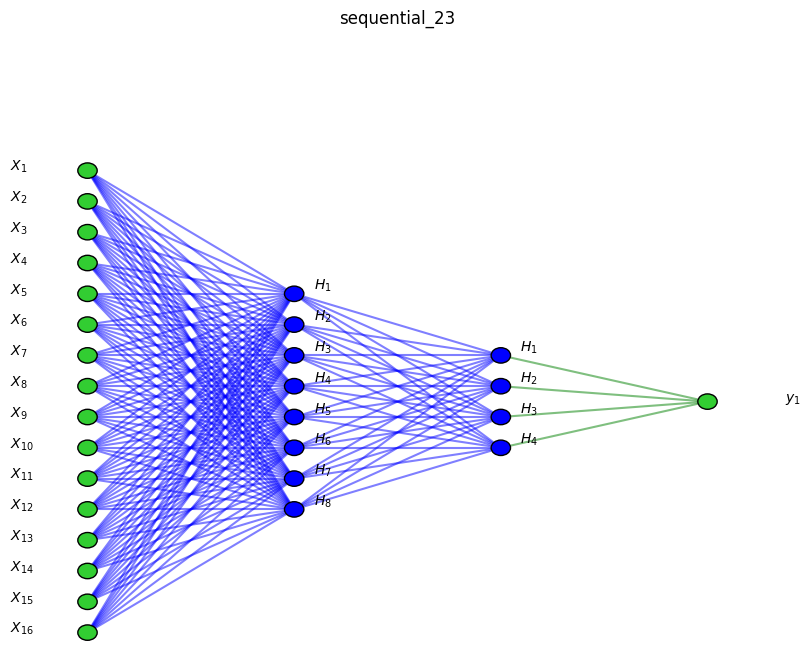

In [233]:
visualize_nn(model)

In [230]:
history = model.fit(X_train_nn, y_train,
          validation_data=(X_test_nn, y_test),batch_size=32,
          epochs=20)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1704.8102 - mae: 30.0183 - val_loss: 5.3255 - val_mae: 1.1579
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.7013 - mae: 1.0935 - val_loss: 2.3855 - val_mae: 0.6718
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.9010 - mae: 0.6194 - val_loss: 1.1631 - val_mae: 0.3653
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9893 - mae: 0.3256 - val_loss: 0.7145 - val_mae: 0.2353
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6157 - mae: 0.2553 - val_loss: 0.4864 - val_mae: 0.2739
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4236 - mae: 0.2057 - val_loss: 0.2722 - val_mae: 0.1569
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2367 - mae: 0.1667 - val_loss: 0.1607 - val_mae: 0.1133
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1411 - mae: 0.1351 - val_loss: 0.0955 - val_mae: 0.1228
Epoch 9/20
1750/1750 ━━━━━━━━━━━━━━━

In [38]:
# You can use this function to see how your model improves over time
def plot_history(history, metric=None):
  """plot loss and passed metric.  metric is passed as string and must match 'metric'
  argument in the compile step"""
  fig, axes = plt.subplots(2,1, figsize = (5,10))
  axes[0].plot(history.history['loss'], label = "train")
  axes[0].plot(history.history['val_loss'], label='test')
  axes[0].set_title('Loss')
  axes[0].legend()
  if metric:
    axes[1].plot(history.history[metric], label = 'train')
    axes[1].plot(history.history['val_' + metric], label = 'test')
    axes[1].set_title(metric)
    axes[1].legend()

  plt.show()

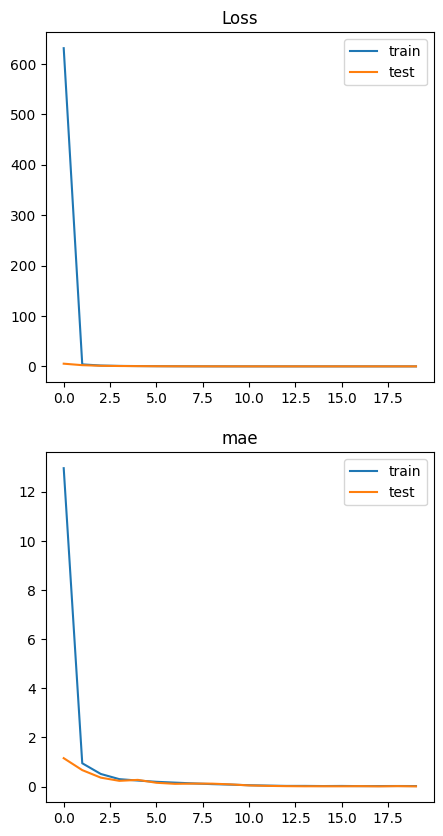

In [231]:
plot_history(history, metric='mae')

Au-delà de 20 epoch le modèle deviendrait overfitted

In [40]:
y_pred_test = model.predict(X_test_nn)
y_pred_train = model.predict(X_train_nn)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print('train rmse', np.sqrt(train_mse))
print('test rmse', np.sqrt(test_mse))

750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 971us/step
train rmse 0.052376880591980084
test rmse 0.052802108600009424


Pas d'overfitting, ni d'underfitting car les deux rmse sont très proches.

Conclusion : Les performances à la fin de l'entrainement montre que le modèle se généralise bien.